<h2 style="color:#1f77b4;">Lección 3: Obtención de datos desde archivos</h2>

<h3>Parte 1</h3>

<h4>Leyendo un archivo CSV</h4>

In [1]:
import pandas as pd

# Leer un archivo CSV básico
df = pd.read_csv('Titanic-Dataset.csv')

# Mostrar las primeras filas
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<h5>Opciones para leer archivos CSV</h5>

<p>1. Leer un archivo CSV con punto y coma como delimitador</p>

In [2]:
df = pd.read_csv("datos_punto_y_coma.csv", sep=";")
print(df.head())

   id nombre  edad  ventas
0   1    Ana    25    1200
1   2   Juan    30    1500
2   3  María    28    1100
3   4  Pedro    35    1800


<p>2. Leer un archivo CSV con tabulación como delimitador</p>

In [3]:
df = pd.read_csv("datos_tab.csv", sep="\t")
print(df.head())

   id nombre  edad  ventas
0   1    Ana    25    1200
1   2   Juan    30    1500
2   3  María    28    1100
3   4  Pedro    35    1800


<h4>Escribiendo un archivo CSV</h4>
Para guardar un DataFrame en un archivo CSV, se utiliza el método to_csv().

In [ ]:
df = pd.DataFrame({
    "id": [1, 2, 3, 4],
    "nombre": ["Ana", "Juan", "María", "Pedro"],
    "edad": [25, 30, 28, 35],
    "ventas": [1200, 1500, 1100, 1800]
})

print("DataFrame original:")
print(df)

# 2) Guardar un DataFrame en un archivo CSV (incluye el índice por defecto)
df.to_csv("nuevo_datos.csv")
print("\nSe creó: nuevo_datos.csv (con índice)")

# 3) Guardar sin incluir el índice
df.to_csv("nuevo_datos_sin_indice.csv", index=False)
print("Se creó: nuevo_datos_sin_indice.csv (sin índice)")


<h3>Archivos Excel</h3>

In [ ]:
import pandas as pd

excel_path="Valor del Dolar.xlsx"

# Leer un archivo Excel
df = pd.read_excel(excel_path)

# Mostrar las primeras filas
print(df.head())


In [ ]:
# si da error Instalar -> pip install openpyxl


In [ ]:
# 1) Ver hojas disponibles
xls = pd.ExcelFile(excel_path)
print("Hojas disponibles:", xls.sheet_names)

In [ ]:
# 2) Leer una hoja por nombre (ajusta el nombre real)
df = pd.read_excel(excel_path, sheet_name=xls.sheet_names[0])
display(df.head())

In [ ]:
# 3) Leer una hoja por índice
df0 = pd.read_excel(excel_path, sheet_name=0)
df0

In [ ]:
# 4) Leer múltiples hojas (diccionario de DataFrames)
dfs = pd.read_excel(excel_path, sheet_name=xls.sheet_names[:2])
print("Hojas cargadas:", list(dfs.keys()))

In [ ]:
dfs

<h2>Leer tablas web con pandas</h2>

In [ ]:
#%pip install requests

In [ ]:
#%pip install lxml


In [ ]:
import pandas as pd
import requests
from io import StringIO

url = "https://es.wikipedia.org/wiki/Anexo:Pa%C3%ADses_por_PIB_(PPA)_per_c%C3%A1pita"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0 Safari/537.36",
    "Accept-Language": "es-ES,es;q=0.9"
}

html = requests.get(url, headers=headers, timeout=30).text
df_list = pd.read_html(StringIO(html))

# Ver cuántas tablas y una “vista rápida” de cada una
print("Cantidad de tablas:", len(df_list))
for i, t in enumerate(df_list):
    print(i, t.shape, "->", list(t.columns)[:6])

In [ ]:
df = df_list[2].copy()
df.head()

In [ ]:
# 5) Renombrar columnas (explícito)
df = df.rename(columns={
    "Pos.": "posicion",
    "País": "pais",
    "PIB per cápita (PPA) Dólares internacionales": "pib_ppa_per_capita",
    "Δ": "delta"
})
df.head()

In [ ]:
# Limpieza
# - quitar referencias tipo [1], [nota 2], etc.
df = df.replace(r"\[.*?\]", "", regex=True)
df.head()

In [ ]:
# - limpiar espacios raros
df["pais"] = df["pais"].astype(str).str.strip()
df.head(100)

In [ ]:
# Convertir pib a número (quita separadores y cosas no numéricas)
df["pib_ppa_per_capita"] = (
    df["pib_ppa_per_capita"]
    .astype(str)                                # fuerza a que todos los valores de la columna pais sean texto
    .str.replace(r"[^\d,.\-]", "", regex=True)  # deja solo dígitos y signos
    .str.replace(".", "", regex=False)          # por si viene con separador de miles "."
    .str.replace(",", "", regex=False)          # por si viene con separador de miles ","
)
df.head(100)

In [ ]:
# Convertir pib a número 
df["pib_ppa_per_capita"] = pd.to_numeric(df["pib_ppa_per_capita"], errors="coerce")
df.head(100)

In [ ]:
# - convertir posición a número
df["posicion"] = pd.to_numeric(df["posicion"], errors="coerce")
df.head(100)

In [ ]:
# - eliminar filas con faltantes relevantes
df = df.dropna(subset=["posicion", "pais", "pib_ppa_per_capita"])
df.head(100)

1) sort_values("posicion"): Ordena las filas según la columna posicion.
2) reset_index(drop=True): reset_index() crea un índice nuevo 0,1,2,3… y drop=True significa: No guardes el índice anterior como una columna extra

In [ ]:
# Ordenar por posición
df = df.sort_values("posicion").reset_index(drop=True)
df.head(100)

In [ ]:
# 7) Guardar a CSV
df.to_csv("pib_ppa_per_capita.csv", index=False, encoding="utf-8")

<h3>Parte 2</h3>

Datos desde https://datosabiertos.fonasa.cl/

Archivo_desde = "https://public.tableau.com/views/PropuestaTableroGRD/PropuestaTableroGRD?%3AshowVizHome=no#1"


<h3>Lectura por fragmentos (chunks)</h3>

<p>chunks es una forma de leer el archivo por partes, en vez de cargarlo completo en memoria.</p>
<p>Pandas no te entrega un DataFrame único. 
Te entrega un iterador que va produciendo DataFrames de 1000 filas cada vez.
</p>

En la práctica significa:
* lees 1000 filas → las procesas → sigues con las siguientes 1000
* así puedes trabajar con archivos grandes sin “reventar” la RAM
* y puedes ir guardando resultados a medida que avanzas

In [1]:
import pandas as pd

# Leer un archivo CSV en fragmentos de 1000 filas
chunks = pd.read_csv(
    "GRD_PUBLICO_2019.txt",
    sep="|",                 # ajusta si corresponde
    encoding="latin1",
    chunksize=1000,
    engine="python",         # más tolerante que el C engine
    on_bad_lines="skip"     # salta filas problemáticas
)

In [5]:
chunk1 = next(chunks)  # primeras 1000
chunk1.shape

(1000, 129)

In [7]:
chunk1.head()

,COD_HOSPITAL,CIP_ENCRIPTADO,SEXO,FECHA_NACIMIENTO,ETNIA,PROVINCIA,COMUNA,NACIONALIDAD,PREVISION,SERVICIO_SALUD,...,FECHAPROCEDIMIENTO1,FECHAINTERV1,ESPECIALIDADINTERVENCION,MEDICOALTA_ENCRIPTADO,USOSPABELLON,IR_29301_COD_GRD,IR_29301_PESO,IR_29301_SEVERIDAD,IR_29301_MORTALIDAD,HOSPPROCEDENCIA
0,118100,1314867,MUJER,1988-06-19,OTRO,CONCEPCION,SAN PEDRO DE LA PAZ,CHILE,FONASA INSTITUCIONAL - (MAI) A,CONCEPCIÃN,...,NaN,2019-03-02,OBSTETRICIA Y GINECOLOGÃA,2932,1.0,146102,"0,5744",2,1,NaN
1,118100,1354418,MUJER,1988-03-27,OTRO,CONCEPCION,SAN PEDRO DE LA PAZ,CHILE,FONASA INSTITUCIONAL - (MAI) D,CONCEPCIÃN,...,NaN,NaN,NaN,2932,NaN,134161,"0,2951",1,1,NaN
2,118100,239861,MUJER,2017-06-17,OTRO,CONCEPCION,CONCEPCIÃN,CHILE,FONASA INSTITUCIONAL - (MAI) B,CONCEPCIÃN,...,NaN,NaN,NaN,2932,NaN,64182,"0,6736",2,2,NaN
3,118100,330326,HOMBRE,2017-12-04,OTRO,CONCEPCION,CONCEPCIÃN,CHILE,FONASA INSTITUCIONAL - (MAI) A,CONCEPCIÃN,...,NaN,NaN,NaN,2932,NaN,64172,"0,5475",2,2,NaN
4,118100,1369293,MUJER,1995-12-06,OTRO,CONCEPCION,FLORIDA,CHILE,FONASA INSTITUCIONAL - (MAI) C,CONCEPCIÃN,...,NaN,NaN,NaN,2932,NaN,134141,"0,3107",1,1,NaN


In [9]:
chunk2 = next(chunks)  # siguientes 1000
chunk2.shape

(1000, 129)

In [11]:
chunk1.to_csv("chunk1.csv", index=False, encoding="utf-8")

<h3>Selección de columnas específicas</h3>

In [13]:
# Leer solo las columnas necesarias
columnas = ['CIP_ENCRIPTADO','SEXO','FECHA_NACIMIENTO']
df = pd.read_csv('chunk1.csv', usecols=columnas)
df.head()


,CIP_ENCRIPTADO,SEXO,FECHA_NACIMIENTO
0,1314867,MUJER,1988-06-19
1,1354418,MUJER,1988-03-27
2,239861,MUJER,2017-06-17
3,330326,HOMBRE,2017-12-04
4,1369293,MUJER,1995-12-06


<h3>Especificación de tipos de datos</h3>
Definir los tipos de datos de antemano puede mejorar significativamente el rendimiento y reducir el uso de memoria:

Especificar tipos de datos precisos puede reducir el uso de memoria hasta en un 50% en algunos casos

In [15]:
# Definir tipos de datos para cada columna
tipos = {
    'COD_HOSPITAL': 'int32',
    'CIP_ENCRIPTADO': 'int32'
}

# Leer el archivo con los tipos especificados
df = pd.read_csv('chunk1.csv', dtype=tipos, parse_dates=['FECHA_NACIMIENTO'])
df.head()


,COD_HOSPITAL,CIP_ENCRIPTADO,SEXO,FECHA_NACIMIENTO,ETNIA,PROVINCIA,COMUNA,NACIONALIDAD,PREVISION,SERVICIO_SALUD,...,FECHAPROCEDIMIENTO1,FECHAINTERV1,ESPECIALIDADINTERVENCION,MEDICOALTA_ENCRIPTADO,USOSPABELLON,IR_29301_COD_GRD,IR_29301_PESO,IR_29301_SEVERIDAD,IR_29301_MORTALIDAD,HOSPPROCEDENCIA
0,118100,1314867,MUJER,1988-06-19,OTRO,CONCEPCION,SAN PEDRO DE LA PAZ,CHILE,FONASA INSTITUCIONAL - (MAI) A,CONCEPCIÃN,...,NaN,2019-03-02,OBSTETRICIA Y GINECOLOGÃA,2932,1.0,146102,"0,5744",2,1,NaN
1,118100,1354418,MUJER,1988-03-27,OTRO,CONCEPCION,SAN PEDRO DE LA PAZ,CHILE,FONASA INSTITUCIONAL - (MAI) D,CONCEPCIÃN,...,NaN,NaN,NaN,2932,NaN,134161,"0,2951",1,1,NaN
2,118100,239861,MUJER,2017-06-17,OTRO,CONCEPCION,CONCEPCIÃN,CHILE,FONASA INSTITUCIONAL - (MAI) B,CONCEPCIÃN,...,NaN,NaN,NaN,2932,NaN,64182,"0,6736",2,2,NaN
3,118100,330326,HOMBRE,2017-12-04,OTRO,CONCEPCION,CONCEPCIÃN,CHILE,FONASA INSTITUCIONAL - (MAI) A,CONCEPCIÃN,...,NaN,NaN,NaN,2932,NaN,64172,"0,5475",2,2,NaN
4,118100,1369293,MUJER,1995-12-06,OTRO,CONCEPCION,FLORIDA,CHILE,FONASA INSTITUCIONAL - (MAI) C,CONCEPCIÃN,...,NaN,NaN,NaN,2932,NaN,134141,"0,3107",1,1,NaN


<h3>Filtrado durante la lectura</h3>
Es posible aplicar filtros durante la lectura para cargar solo las filas que cumplen ciertas condiciones:

In [17]:
# Leer solo las filas que cumplen la condición
df = pd.read_csv('chunk1.csv', 
                chunksize=1000, 
                iterator=True)
df_filtrado = pd.concat([chunk[chunk['SEXO'] == "MUJER"] for chunk in df])


In [21]:
df_filtrado.shape

(618, 129)

In [19]:
df_filtrado["SEXO"].unique()

array(['MUJER'], dtype=object)

<h3>Ejemplo de integración completa</h3>

In [ ]:
import pandas as pd

data = [
    {"Gasto": 120.5, "Frecuencia": 2, "Categoría": "Básico"},
    {"Gasto": 85.0, "Frecuencia": 1, "Categoría": "Básico"},
    {"Gasto": 300.0, "Frecuencia": 4, "Categoría": "Premium"},
    {"Gasto": 450.75, "Frecuencia": 6, "Categoría": "Premium"},
    {"Gasto": 210.2, "Frecuencia": 3, "Categoría": "Estándar"},
    {"Gasto": 190.0, "Frecuencia": 3, "Categoría": "Estándar"},
    {"Gasto": 560.0, "Frecuencia": 7, "Categoría": "Premium"},
    {"Gasto": 95.5, "Frecuencia": 2, "Categoría": "Básico"},
    {"Gasto": None, "Frecuencia": 5, "Categoría": "Estándar"},
    {"Gasto": 180.0, "Frecuencia": None, "Categoría": "Básico"},
    {"Gasto": 275.0, "Frecuencia": 4, "Categoría": "Estándar"},
    {"Gasto": 620.3, "Frecuencia": 8, "Categoría": "Premium"},
]

pd.DataFrame(data).to_csv("clientes.csv", index=False, encoding="utf-8")


In [ ]:
#%pip install seaborn

In [ ]:
#%pip install scikit-learn

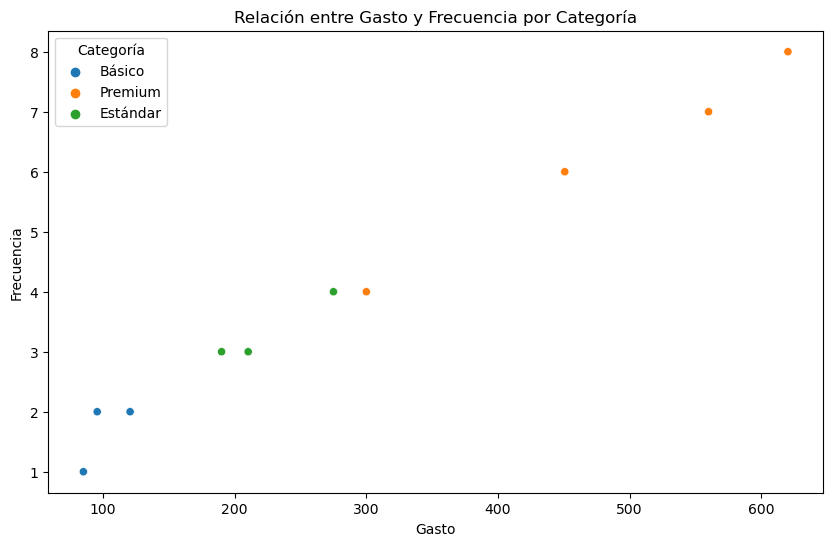

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# 1. Obtener datos
df = pd.read_csv('clientes.csv')

# 2. Procesar datos
df = df.dropna()
df['Gasto'] = df['Gasto'].astype(float)
df['Frecuencia'] = df['Frecuencia'].astype(int)

# 3. Análisis exploratorio
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Gasto', y='Frecuencia', hue='Categoría')
plt.title('Relación entre Gasto y Frecuencia por Categoría')
plt.show()
#plt.savefig('analisis_exploratorio.png')

# 4. Aplicar modelo
X = df[['Gasto', 'Frecuencia']]
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

# 5. Guardar resultados
df.to_excel('clientes_segmentados.xlsx', index=False)


<h3>Manejo de datos faltantes</h3>

In [25]:
df = pd.read_csv('clientes.csv')
df


,Gasto,Frecuencia,Categoría
0,120.50,2.0,Básico
1,85.00,1.0,Básico
2,300.00,4.0,Premium
3,450.75,6.0,Premium
4,210.20,3.0,Estándar
5,190.00,3.0,Estándar
6,560.00,7.0,Premium
7,95.50,2.0,Básico
8,NaN,5.0,Estándar
9,180.00,NaN,Básico


In [27]:
# Detectar valores faltantes
df.isnull().sum()


Gasto         1
Frecuencia    1
Categoría     0
dtype: int64

In [29]:
# Eliminar filas con valores faltantes
df_limpio = df.dropna()
df_limpio.isnull().sum()


Gasto         0
Frecuencia    0
Categoría     0
dtype: int64

In [31]:
df_limpio

,Gasto,Frecuencia,Categoría
0,120.50,2.0,Básico
1,85.00,1.0,Básico
2,300.00,4.0,Premium
3,450.75,6.0,Premium
4,210.20,3.0,Estándar
5,190.00,3.0,Estándar
6,560.00,7.0,Premium
7,95.50,2.0,Básico
10,275.00,4.0,Estándar
11,620.30,8.0,Premium


In [33]:
df_relleno = df.fillna(0)  # Con ceros
df_relleno.isnull().sum()

Gasto         0
Frecuencia    0
Categoría     0
dtype: int64

In [35]:
df_relleno

,Gasto,Frecuencia,Categoría
0,120.50,2.0,Básico
1,85.00,1.0,Básico
2,300.00,4.0,Premium
3,450.75,6.0,Premium
4,210.20,3.0,Estándar
5,190.00,3.0,Estándar
6,560.00,7.0,Premium
7,95.50,2.0,Básico
8,0.00,5.0,Estándar
9,180.00,0.0,Básico


In [37]:
df_relleno = df.copy()

In [39]:
df_relleno.describe()

,Gasto,Frecuencia
count,11.000000,11.000000
mean,280.659091,4.090909
std,185.541751,2.211540
min,85.000000,1.000000
25%,150.250000,2.500000
50%,210.200000,4.000000
75%,375.375000,5.500000
max,620.300000,8.000000


In [41]:

df_relleno = df.fillna(df.mean(numeric_only=True)) # Eso calcula el promedio solo de las columnas numéricas (Gasto, Frecuencia) y rellena sus NaN con ese promedio.


In [43]:
df_relleno

,Gasto,Frecuencia,Categoría
0,120.500000,2.000000,Básico
1,85.000000,1.000000,Básico
2,300.000000,4.000000,Premium
3,450.750000,6.000000,Premium
4,210.200000,3.000000,Estándar
5,190.000000,3.000000,Estándar
6,560.000000,7.000000,Premium
7,95.500000,2.000000,Básico
8,280.659091,5.000000,Estándar
9,180.000000,4.090909,Básico


<h3>Detección y manejo de valores atípicos</h3>

<p>Tenemos un listado de clientes con su gasto mensual.
La mayoría gasta montos razonables… pero hay uno o dos valores raros, muy altos, que pueden distorsionar el análisis.

Eso es exactamente lo que llamamos valores atípicos (outliers).</p>

In [45]:
#Creamos un dataset de ejemplo
df = pd.DataFrame({
    "Cliente": ["A", "B", "C", "D", "E", "F", "G", "H"],
    "Gasto":   [120, 150, 130, 140, 160, 155, 145, 1200]
})

df

,Cliente,Gasto
0,A,120
1,B,150
2,C,130
3,D,140
4,E,160
5,F,155
6,G,145
7,H,1200


<h4>Detección de outliers con el método IQR</h4>

Entendiendo la idea del método IQR

* Q1 (25%): valores bajos normales
* Q3 (75%): valores altos normales
* IQR = rango “normal” del dato

Todo lo que quede muy lejos de ese rango se considera atípico.

Calcular Q1, Q3 e IQR

In [47]:
Q1 = df["Gasto"].quantile(0.25)
Q3 = df["Gasto"].quantile(0.75)
IQR = Q3 - Q1

Q1, Q3, IQR

(137.5, 156.25, 18.75)

Definir límites

In [49]:
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR


In [51]:
limite_inferior, limite_superior

(109.375, 184.375)

Identificar los outliers

In [53]:
outliers = df[
    (df["Gasto"] < limite_inferior) |
    (df["Gasto"] > limite_superior)
]

outliers

,Cliente,Gasto
7,H,1200


¿Qué hacemos con los outliers?

In [55]:
# 1 Eliminarlos
df_sin_outliers = df[
    (df["Gasto"] >= limite_inferior) &
    (df["Gasto"] <= limite_superior)
]

df_sin_outliers


,Cliente,Gasto
0,A,120
1,B,150
2,C,130
3,D,140
4,E,160
5,F,155
6,G,145


In [57]:
# 2 Reemplazarlos
df_reemplazado = df.copy()

# Convertir en el mismo df donde vas a reemplazar
df_reemplazado["Gasto"] = pd.to_numeric(df_reemplazado["Gasto"], errors="coerce").astype(float)

mediana = df_reemplazado["Gasto"].median()

mask = (df_reemplazado["Gasto"] < limite_inferior) | (df_reemplazado["Gasto"] > limite_superior)
df_reemplazado.loc[mask, "Gasto"] = float(mediana)

df_reemplazado



,Cliente,Gasto
0,A,120.0
1,B,150.0
2,C,130.0
3,D,140.0
4,E,160.0
5,F,155.0
6,G,145.0
7,H,147.5


<h3>Formatos alternativos para grandes volúmenes de datos</h3>

In [59]:
import pandas as pd

df = pd.DataFrame({
    "id": [1, 2, 3, 4],
    "cliente": ["A", "B", "C", "D"],
    "gasto": [120.5, 85.0, 300.0, 450.75],
    "fecha": pd.to_datetime(["2026-01-01", "2026-01-02", "2026-01-03", "2026-01-04"])
})

df


,id,cliente,gasto,fecha
0,1,A,120.50,2026-01-01
1,2,B,85.00,2026-01-02
2,3,C,300.00,2026-01-03
3,4,D,450.75,2026-01-04


<h4>Parquet (ideal para análisis, comprimido, rápido)</h4>

In [ ]:
#pip install pyarrow

In [61]:
# Guardar el DataFrame en formato Parquet
df.to_parquet("datos.parquet", index=False) # guardar
df_parquet = pd.read_parquet("datos.parquet") # leer
df_parquet.head()


,id,cliente,gasto,fecha
0,1,A,120.50,2026-01-01
1,2,B,85.00,2026-01-02
2,3,C,300.00,2026-01-03
3,4,D,450.75,2026-01-04


HDF5 (útil para guardar “datasets” grandes y estructurados)

In [ ]:
#pip install tables


In [63]:
df.to_hdf("datos.h5", key="df", mode="w")      # guardar
df_hdf = pd.read_hdf("datos.h5", key="df")     # leer
df_hdf.head()


,id,cliente,gasto,fecha
0,1,A,120.50,2026-01-01
1,2,B,85.00,2026-01-02
2,3,C,300.00,2026-01-03
3,4,D,450.75,2026-01-04


Feather (muy rápido, intercambio Python ↔ R, también usa Arrow)

In [ ]:
# pip install pyarrow

In [64]:
df.to_feather("datos.feather")            # guardar
df_feather = pd.read_feather("datos.feather")  # leer
df_feather.head()

,id,cliente,gasto,fecha
0,1,A,120.50,2026-01-01
1,2,B,85.00,2026-01-02
2,3,C,300.00,2026-01-03
3,4,D,450.75,2026-01-04


<h3>Conexión con bases de datos</h3>
SQLite viene incluido por defecto con Python.

SQLite en 1 minuto

¿Qué es?
SQLite es una base de datos relacional que vive en un archivo .db.
No necesita servidor (a diferencia de PostgreSQL/MySQL). Ideal para demos, proyectos pequeños y prototipos.

In [67]:
import sqlite3
print(sqlite3.sqlite_version)


3.41.2


In [71]:
import sqlite3
import pandas as pd

# Conectar (o crear) base
conn = sqlite3.connect("prueba.db")

# Crear DataFrame simple
df = pd.DataFrame({
    "id": [1, 2, 3,4],
    "nombre": ["Ana", "Juan", "María","Ingrid"]
})

# Guardar en SQLite
df.to_sql("personas", conn, if_exists="replace", index=False)

# Leer desde SQLite
df_leido = pd.read_sql("SELECT * FROM personas", conn)
print(df_leido)

conn.close()


   id  nombre
0   1     Ana
1   2    Juan
2   3   María
3   4  Ingrid


<h4>SQLite desde Python</h4>

Insertar un registro

In [73]:
conn = sqlite3.connect("prueba.db")
conn.execute("INSERT INTO personas (id, nombre) VALUES (?, ?)", (5, "Sofía"))
conn.commit()
conn.close()


In [75]:
# Leer desde SQLite
conn = sqlite3.connect("prueba.db")
df_leido = pd.read_sql("SELECT * FROM personas", conn)
print(df_leido)

   id  nombre
0   1     Ana
1   2    Juan
2   3   María
3   4  Ingrid
4   5   Sofía


Actualizar

In [77]:
conn = sqlite3.connect("prueba.db")
conn.execute("UPDATE personas SET nombre = ? WHERE id = ?", ("Juan Pablo", 2))
conn.commit()
conn.close()


In [79]:
# Leer desde SQLite
conn = sqlite3.connect("prueba.db")
df_leido = pd.read_sql("SELECT * FROM personas", conn)
print(df_leido)

   id      nombre
0   1         Ana
1   2  Juan Pablo
2   3       María
3   4      Ingrid
4   5       Sofía


Eliminar

In [81]:
conn = sqlite3.connect("prueba.db")
conn.execute("DELETE FROM personas WHERE id = ?", (1,))
conn.commit()
conn.close()


In [83]:
conn = sqlite3.connect("prueba.db")
df = pd.read_sql("SELECT * FROM personas", conn)
conn.close()
df


,id,nombre
0,2,Juan Pablo
1,3,María
2,4,Ingrid
3,5,Sofía


<h3>Obtención de datos desde APIs</h3>
Muchos servicios web ofrecen APIs que permiten acceder a datos de forma programática. Pandas puede trabajar con estos datos una vez obtenidos:

In [85]:
import requests
import pandas as pd

# Realizar solicitud a la API
url = 'https://api.exchangerate-api.com/v4/latest/USD'
respuesta = requests.get(url)
datos = respuesta.json()

# Convertir a DataFrame
df = pd.DataFrame(datos)
df


,provider,WARNING_UPGRADE_TO_V6,terms,base,date,time_last_updated,rates
USD,https://www.exchangerate-api.com,https://www.exchangerate-api.com/docs/free,https://www.exchangerate-api.com/terms,USD,2026-01-19,1768780801,1.00
AED,https://www.exchangerate-api.com,https://www.exchangerate-api.com/docs/free,https://www.exchangerate-api.com/terms,USD,2026-01-19,1768780801,3.67
AFN,https://www.exchangerate-api.com,https://www.exchangerate-api.com/docs/free,https://www.exchangerate-api.com/terms,USD,2026-01-19,1768780801,65.04
ALL,https://www.exchangerate-api.com,https://www.exchangerate-api.com/docs/free,https://www.exchangerate-api.com/terms,USD,2026-01-19,1768780801,83.11
AMD,https://www.exchangerate-api.com,https://www.exchangerate-api.com/docs/free,https://www.exchangerate-api.com/terms,USD,2026-01-19,1768780801,379.94
...,...,...,...,...,...,...,...
YER,https://www.exchangerate-api.com,https://www.exchangerate-api.com/docs/free,https://www.exchangerate-api.com/terms,USD,2026-01-19,1768780801,238.27
ZAR,https://www.exchangerate-api.com,https://www.exchangerate-api.com/docs/free,https://www.exchangerate-api.com/terms,USD,2026-01-19,1768780801,16.42
ZMW,https://www.exchangerate-api.com,https://www.exchangerate-api.com/docs/free,https://www.exchangerate-api.com/terms,USD,2026-01-19,1768780801,19.93
ZWG,https://www.exchangerate-api.com,https://www.exchangerate-api.com/docs/free,https://www.exchangerate-api.com/terms,USD,2026-01-19,1768780801,25.61


In [87]:
# Procesar y guardar
df.to_csv('datos_api.csv', index=False)

<h3>Ejemplo de obtención desde Yahoo Finance</h3>

In [91]:
pip install yfinance

  Using cached yfinance-1.0-py2.py3-none-any.whl.metadata (6.0 kB)
  Using cached multitasking-0.0.12-py3-none-any.whl
  Using cached peewee-3.19.0-py3-none-any.whl.metadata (7.0 kB)
  Using cached curl_cffi-0.13.0-cp39-abi3-macosx_10_9_x86_64.whl.metadata (13 kB)
Using cached yfinance-1.0-py2.py3-none-any.whl (127 kB)
Using cached curl_cffi-0.13.0-cp39-abi3-macosx_10_9_x86_64.whl (5.7 MB)
Using cached peewee-3.19.0-py3-none-any.whl (411 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [yfinance]3/4 [yfinance]]
Note: you may need to restart the kernel to use updated packages.


[*********************100%***********************]  1 of 1 completed


Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2025-01-17  228.944534  231.244131  227.451288  231.074899  68488300
2025-01-21  221.637589  223.409573  218.392272  222.991466  98070400
2025-01-22  222.822235  223.110923  218.800416  218.800416  64126500
2025-01-23  222.653000  226.007822  221.299123  223.728139  60234800
2025-01-24  221.776962  224.614137  220.413135  223.767958  54697900


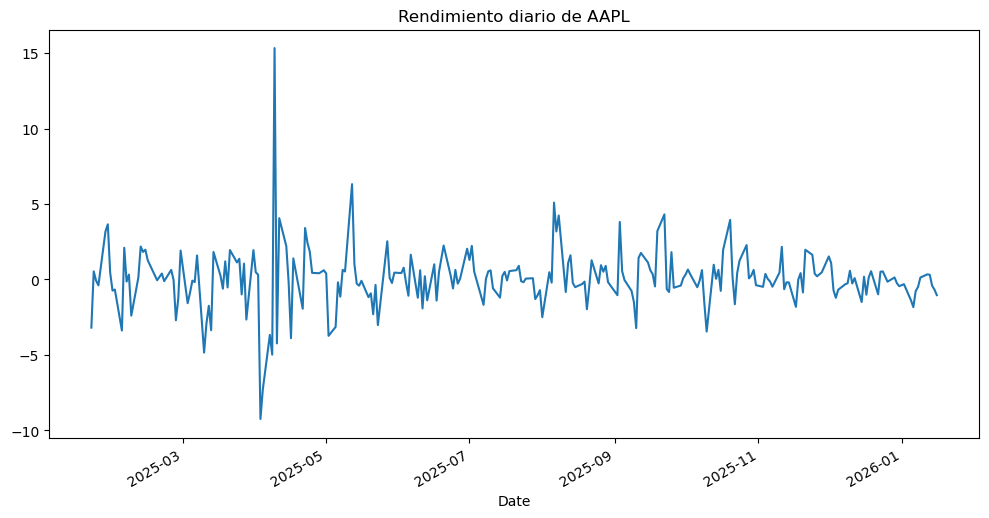

In [1]:
import pandas as pd
import yfinance as yf

# Obtener datos históricos de una acción
ticker = 'AAPL'
periodo = '1y' # 1 año
df = yf.download(ticker, period=periodo)

# Mostrar los primeros registros
print(df.head())

# Guardar en CSV
df.to_csv(f'{ticker}_historico.csv')

# Calcular rendimientos diarios
df['Rendimiento'] = df['Close'].pct_change() * 100

# Visualizar rendimientos
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
df['Rendimiento'].plot()
plt.title(f'Rendimiento diario de {ticker}')
plt.savefig(f'{ticker}_rendimiento.png')
